# Fraud Detection — Model E05 (final)

XGBoost with 8 extra features, trained on the full dataset (746,698 transactions
in 6 files).

This was the best of the 7 setups tested:

| Setup | PR-AUC |
|---|---|
| Rules baseline | — |
| Random Forest (balanced) | 0.282 |
| Random Forest (fixed) | 0.632 |
| Random Forest + features | 0.636 |
| XGBoost | 0.656 |
| **XGBoost + features (this one)** | **0.658** |
| Neural network, 6 x 64 | 0.610 |
| Neural network, 2 x 512 | 0.631 |

Run the cells from top to bottom. Training takes about a minute.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import average_precision_score, roc_auc_score

## 2. Upload the data

Run this cell, click **Choose Files**, and select **all 6 files at once**
(hold Ctrl on Windows or Cmd on Mac). About 130 MB, so it takes a few minutes.
Keep them zipped as `.gz`.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving transactions.csv to transactions.csv


## 3. Load the data

In [4]:
FILE_NAME = "transactions.csv"   # change this if your file has a different name

df = pd.read_csv(FILE_NAME, low_memory=False)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print("Rows:", len(df))
print("Fraud transactions:", df["is_fraud"].sum())

Rows: 746698
Fraud transactions: 1305


## 4. What to predict

In [5]:
TARGET = "is_fraud"
TYPE_COLUMN = "fraud_type"

## 5. The 8 extra features

Each one targets a fraud type the plain model was weak on. They are combinations
of existing columns, written the way a fraud analyst would describe the pattern.

In [6]:
# Account takeover: a new device paying someone new
df["new_device_new_payee"] = ((df["is_new_device"] == 1) & (df["is_new_counterparty"] == 1)).astype(int)
df["new_device_x_amount"] = df["is_new_device"] * df["amount_over_income"]
df["fast_after_login"] = ((df["seconds_since_login"] >= 0) & (df["seconds_since_login"] < 120)).astype(int)
df["vpn_new_device"] = ((df["is_proxy_vpn"] == 1) & (df["is_new_device"] == 1)).astype(int)

# Online card fraud: foreign internet address, no 3-D Secure
df["foreign_ip_no_3ds"] = ((df["ip_country"] != "SA") & (df["entry_mode"] == "ECOM_NO_3DS")).astype(int)

# One payment compared with the whole day's spending
df["share_of_day_spend"] = df["amount_sar"] / (df["amount_sum_24h"] + 1)

# Night activity that is unusual for this customer
df["unusual_night"] = ((df["hour"] <= 5) & (df["hour_deviation_score"] > 2)).astype(int)

# Transfers sitting just under the SAR 20,000 sarie limit
df["near_sarie_cap"] = ((df["channel"] == "IPS_SARIE") & (df["amount_sar"] >= 17000) & (df["amount_sar"] < 20000)).astype(int)

print("Added 8 features")

Added 8 features


## 6. Prepare the columns

Remove IDs, free text, and every label or post-investigation column. Leaving any
label in would let the model cheat.

In [7]:
drop_columns = [
    # IDs
    "txn_id", "timestamp", "booking_date", "account_id", "customer_id",
    "merchant_id", "terminal_id", "counterparty_id", "session_id", "device_id",
    # free text / too many different values
    "merchant_name", "narrative", "corridor", "merchant_city", "txn_city",
    "home_city", "counterparty_bank_code", "os",
    # labels and anything known only after an investigation
    "is_fraud", "fraud_type", "is_suspicious_aml", "aml_typology", "case_id",
    "label_source", "label_available_at", "weight_fraud", "weight_aml",
]

X = df.drop(columns=drop_columns)
y = df[TARGET]

text_columns = X.select_dtypes(exclude="number").columns
X = pd.get_dummies(X, columns=text_columns)
X = X.fillna(0)

print("Columns for the model:", X.shape[1])

Columns for the model: 328


## 7. Split into train, validation and test

Three parts, in time order:

- **Train** (Jan to mid-July): the model learns here.
- **Validation** (mid-July to Aug): compare experiments here.
- **Test** (Aug to Sep): touch **once**, at the very end. For that final run the
  model trains on train + validation together, so it learns from all the past data.

Comparing experiments on the test set and then reporting that same number makes
your results look better than they are. Keep `EVAL = "val"` while experimenting,
and switch to `"test"` only for the final numbers in your report.

In [8]:
order = df["timestamp"].sort_values().index
cut1 = int(len(order) * 0.7)
cut2 = int(len(order) * 0.8)

train_rows = order[:cut1]
val_rows = order[cut1:cut2]
test_rows = order[cut2:]

EVAL = "val"          # change to "test" ONCE, at the end

if EVAL == "val":
    eval_rows = val_rows
else:
    # Final run: the settings are decided, so train on train + validation
    # (all data before the test period), then score the test period once
    train_rows = order[:cut2]
    eval_rows = test_rows

X_train, y_train = X.loc[train_rows], y.loc[train_rows]
X_eval, y_eval = X.loc[eval_rows], y.loc[eval_rows]
eval_data = df.loc[eval_rows]

print("Train:     ", len(X_train), "rows,", y_train.sum(), "fraud")
print(f"{EVAL:<10}", len(X_eval), "rows,", y_eval.sum(), "fraud")
print("Period:", eval_data["timestamp"].min().date(), "to", eval_data["timestamp"].max().date())

Train:      522688 rows, 963 fraud
val        74670 rows, 113 fraud
Period: 2026-07-16 to 2026-08-11


## 8. Baseline: a static rules engine

Fixed thresholds, of the kind many banks still run. The model has to beat it.

In [9]:
rule_flag = (
    (eval_data["amount_sar"] > 20000)
    | (eval_data["txn_count_1h"] > 4)
    | (eval_data["mcc_risk_score"] > 0.7)
    | (eval_data["is_high_risk_jurisdiction"] == 1)
).astype(int)

print("Rule flagged:", rule_flag.sum(), "transactions")
print("Precision:", round(precision_score(y_eval, rule_flag), 3))
print("Recall:   ", round(recall_score(y_eval, rule_flag), 3))

Rule flagged: 4790 transactions
Precision: 0.006
Recall:    0.248


## 9. Train the model

In [10]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Done training")

Done training


## 10. Score and choose an alert budget

The model gives each transaction a score. Instead of a fixed 0.5 cut-off, flag
the highest-scoring transactions up to the number of alerts analysts can review.
A 0.5 threshold means nothing to a bank; an alert budget does.

In [11]:
scores = model.predict_proba(X_eval)[:, 1]

# Alert budget per day, so validation and test are compared fairly
# (the test period is longer than the validation period)
ALERTS_PER_DAY = 6
days = (eval_data["timestamp"].max() - eval_data["timestamp"].min()).days + 1
ALERTS = ALERTS_PER_DAY * days
print("Days in this period:", days, "| alert budget:", ALERTS)

threshold = np.sort(scores)[-ALERTS]
predictions = (scores >= threshold).astype(int)

print("Threshold used:", round(threshold, 4))
print()
print(classification_report(y_eval, predictions, target_names=["normal", "fraud"]))

Days in this period: 27 | alert budget: 162
Threshold used: 0.0102

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     74557
       fraud       0.57      0.82      0.68       113

    accuracy                           1.00     74670
   macro avg       0.79      0.91      0.84     74670
weighted avg       1.00      1.00      1.00     74670



In [12]:
cm = confusion_matrix(y_eval, predictions)

print("              predicted normal   predicted fraud")
print("actually normal  ", cm[0][0], "           ", cm[0][1])
print("actually fraud   ", cm[1][0], "             ", cm[1][1])
print()
print("Caught:      ", cm[1][1], "fraud transactions")
print("Missed:      ", cm[1][0])
print("False alarms:", cm[0][1])

              predicted normal   predicted fraud
actually normal   74488             69
actually fraud    20               93

Caught:       93 fraud transactions
Missed:       20
False alarms: 69


## 11. Model vs rules

In [13]:
print("                 Precision   Recall")
print("Static rules     ", round(precision_score(y_eval, rule_flag), 3),
      "     ", round(recall_score(y_eval, rule_flag), 3))
print("XGBoost (E05)    ", round(precision_score(y_eval, predictions), 3),
      "     ", round(recall_score(y_eval, predictions), 3))
print()
print("PR-AUC  (best single number for rare events):", round(average_precision_score(y_eval, scores), 3))
print("ROC-AUC:", round(roc_auc_score(y_eval, scores), 3))

                 Precision   Recall
Static rules      0.006       0.248
XGBoost (E05)     0.574       0.823

PR-AUC  (best single number for rare events): 0.732
ROC-AUC: 0.999


## 12. Precision and recall at different alert budgets

Lower budget means higher precision and lower recall. The bank picks the row
that matches its analyst capacity.

In [14]:
print("Alerts   Precision   Recall")
for k in [50, 100, 200, 300, 600]:
    t = np.sort(scores)[-k]
    flag = (scores >= t).astype(int)
    print(f"{k:5d}     {precision_score(y_eval, flag, zero_division=0):.3f}      {recall_score(y_eval, flag):.3f}")

Alerts   Precision   Recall
   50     0.840      0.372
  100     0.710      0.628
  200     0.495      0.876
  300     0.347      0.920
  600     0.183      0.973


## 13. One alert per account per day

Fraud arrives in bursts, so one attack can use up 8 alerts. Grouping by account
and day means an analyst sees each case once. This catches far more attacks for
the same number of alerts.

In [15]:
alerts = eval_data[["account_id", "timestamp", "case_id", TARGET]].copy()
alerts["score"] = scores
alerts["day"] = alerts["timestamp"].dt.date

account_days = alerts.groupby(["account_id", "day"]).agg(
    score=("score", "max"),
    is_fraud=(TARGET, "max"),
).reset_index().sort_values("score", ascending=False)

fraud_rows = alerts[alerts[TARGET] == 1]
total_cases = fraud_rows["case_id"].nunique()
print("Separate fraud cases in this period:", total_cases)
print()
print("Alerts   Precision   Fraud cases caught")

for k in [50, 100, 200, 300]:
    top = account_days.head(k)
    caught = fraud_rows.merge(top[["account_id", "day"]], on=["account_id", "day"])
    print(f"{k:5d}     {top['is_fraud'].mean():.3f}       {caught['case_id'].nunique()} / {total_cases}")

Separate fraud cases in this period: 37

Alerts   Precision   Fraud cases caught
   50     0.780       30 / 37
  100     0.540       35 / 37
  200     0.295       37 / 37
  300     0.197       37 / 37


`case_id` is used only to **count** cases here. The model never sees it, so
this is not leakage.

## 14. What the model relies on

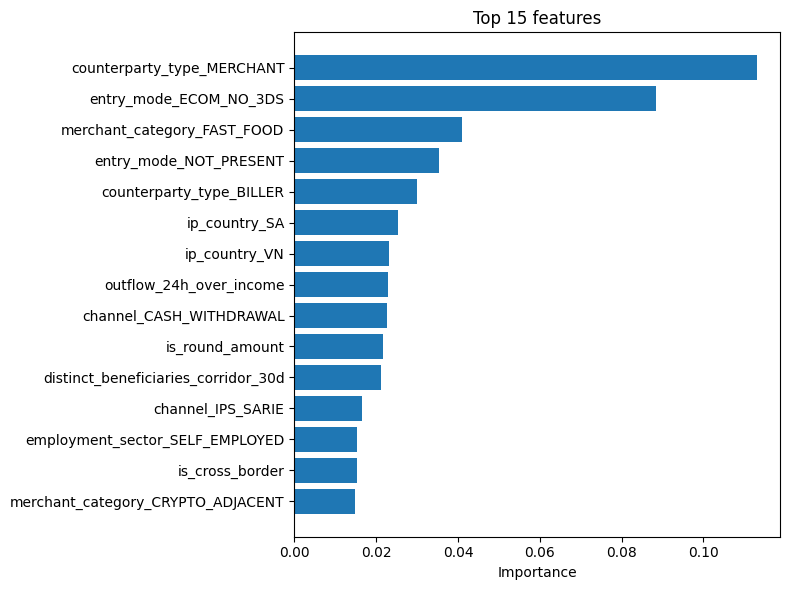

In [16]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
top = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 15 features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 15. Which fraud types it catches

In [17]:
results = eval_data.copy()
results["caught"] = predictions

caught_by_type = results[results[TARGET] == 1].groupby(TYPE_COLUMN)["caught"].agg(["count", "mean"])
print(caught_by_type.rename(columns={"count": "cases", "mean": "share caught"}).round(3))

                        cases  share caught
fraud_type                                 
ACCOUNT_TAKEOVER           19         1.000
APP_SOCIAL_ENGINEERING     23         0.957
ATM_SKIMMING               13         0.923
CARD_TESTING               16         1.000
CNP_FRAUD_BURST            17         0.529
FIRST_PARTY_BUST_OUT       25         0.600


## 16. Save the model

Download these three files from the file panel on the left. The agent will load
them instead of retraining.

In [18]:
joblib.dump(model, "fraud_model_e05.pkl")
joblib.dump(list(X_train.columns), "model_columns.pkl")
joblib.dump({"alerts_per_day": ALERTS_PER_DAY, "threshold": float(threshold), "eval_set": EVAL},
            "model_settings.pkl")

print("Saved fraud_model_e05.pkl, model_columns.pkl, model_settings.pkl")

Saved fraud_model_e05.pkl, model_columns.pkl, model_settings.pkl


## Notes for the report

- Fraud is about 1 in 570 transactions here, close to a real bank, so precision
  is realistic. Don't report accuracy: it stays near 1.00 whatever the model does.
- Recall has a ceiling. About 9% of the fraud in this data is deliberately
  unlabelled (30% for losses under SAR 1,500), because real victims often never
  report.
- Results on synthetic data show the method works, not that it would catch real
  fraudsters. Say so.
- Two headline numbers to quote: precision and recall per transaction at your
  chosen budget, and fraud cases caught per account-day alert from step 13.

In [19]:
model.save_model("fraud_model_e05.json")

In [20]:
import xgboost, sklearn, pandas, numpy
print("xgboost==" + xgboost.__version__)
print("scikit-learn==" + sklearn.__version__)
print("pandas==" + pandas.__version__)
print("numpy==" + numpy.__version__)

xgboost==3.4.1
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
